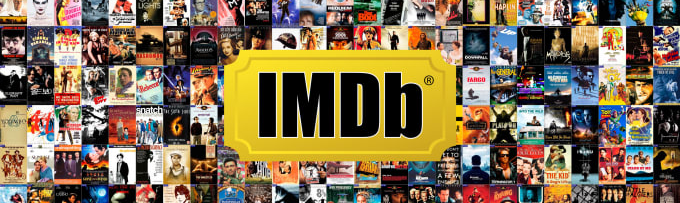


# Desafio

---

*O seguinte projeto tem como proposta principal criar modelos básicos de learning machine para resolver um problema de regressão com target numérica e contínua. Assim, testando conhecimentos de análise exploratória de dados e resolução de problemas de negócio.*

---



**contexto:** Você foi alocado em um time da Indicium contratado por um estúdio de Hollywood chamado PProductions, e agora deve fazer uma análise em cima de um banco de dados cinematográfico para orientar qual tipo de filme deve ser o próximo a ser desenvolvido. Lembre-se que há muito dinheiro envolvido, então a análise deve ser muito detalhada e levar em consideração o máximo de fatores possíveis (a introdução de dados externos é permitida - e encorajada).

## Dicionário de Dados



1.   Series_Title – Nome do filme
2.   Released_Year - Ano de lançamento
1.   Certificate - Classificação etária
1.   Runtime – Tempo de duração
1.   Genre - Gênero
1.   IMDB_Rating - Nota do IMDB
2.   Overview - Overview do filme
2.   Meta_score - Média ponderada de todas as críticas
2.   Director – Diretor
2.   Star1 - Ator/atriz #1
1.   Star2 - Ator/atriz #2
1.   Star3 - Ator/atriz #3
1.   Star4 - Ator/atriz #4
2.   No_of_Votes - Número de votos
2.   Gross - Faturamento

As seguintes perguntas também serão respondidas:

Qual filme você recomendaria para uma pessoa que você não conhece?

Quais são os principais fatores que estão relacionados com alta expectativa de faturamento de um filme?

Quais insights podem ser tirados com a coluna Overview? É possível inferir o gênero do filme a partir dessa coluna?




In [ ]:
# Bibliotecas necessárias
import tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import panel as pn
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
# Montando o drive para acessar nosso dataframe
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Carregando o dataframe
df = pd.read_csv('/content/drive/MyDrive/Desafio_lighthouse/desafio_indicium_imdb.csv')
df.head(10)

,Unnamed: 0,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
1,2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
2,3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
3,4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
4,5,The Lord of the Rings: The Return of the King,2003,U,201 min,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905"
5,6,Pulp Fiction,1994,A,154 min,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762"
6,7,Schindler's List,1993,A,195 min,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818"
7,8,Inception,2010,UA,148 min,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195"
8,9,Fight Club,1999,A,139 min,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102"
9,10,The Lord of the Rings: The Fellowship of the Ring,2001,U,178 min,"Action, Adventure, Drama",8.8,A meek Hobbit from the Shire and eight compani...,92.0,Peter Jackson,Elijah Wood,Ian McKellen,Orlando Bloom,Sean Bean,1661481,"315,544,750"


##Analise Eploratória (EDA)

---



### Estrutura dos dados
Dando uma primeira olhada no dataframe percebemos a presença de uma coluna que não tem uma finalidade realmente útil, então iremos descartar ela.

In [ ]:
df = df.drop(columns=['Unnamed: 0'])

In [ ]:
#Vefificando o formato do dataframe
print (f'Quantidade de linhas: {df.shape[0]} \n')
print (f'Quantidade de colunas: {df.shape[1]}\n')

Quantidade de linhas: 999 

Quantidade de colunas: 15



Algo que também podemos fazer no inicio para facilitar a nossa analise, é separar os generos em colunas diferentes.

In [ ]:
# Criando uma lista dos generos
df['Genre_list'] = df['Genre'].str.split(',')
# Cria uma série onde cada elemento da lista vira uma coluna
df[['Genre_1', 'Genre_2', 'Genre_3']] = df['Genre_list'].apply(lambda x: pd.Series([i for i in x]))
# Dropa as colunas 'Genre' e 'Genre_list' que não são mais necessárias
df = df.drop(columns=['Genre', 'Genre_list'])
df.head(10)


,Series_Title,Released_Year,Certificate,Runtime,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Genre_1,Genre_2,Genre_3
0,The Godfather,1972,A,175 min,9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411",Crime,Drama,NaN
1,The Dark Knight,2008,UA,152 min,9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444",Action,Crime,Drama
2,The Godfather: Part II,1974,A,202 min,9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000",Crime,Drama,NaN
3,12 Angry Men,1957,U,96 min,9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000",Crime,Drama,NaN
4,The Lord of the Rings: The Return of the King,2003,U,201 min,8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,"377,845,905",Action,Adventure,Drama
5,Pulp Fiction,1994,A,154 min,8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,"107,928,762",Crime,Drama,NaN
6,Schindler's List,1993,A,195 min,8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,"96,898,818",Biography,Drama,History
7,Inception,2010,UA,148 min,8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,"292,576,195",Action,Adventure,Sci-Fi
8,Fight Club,1999,A,139 min,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,"37,030,102",Drama,NaN,NaN
9,The Lord of the Rings: The Fellowship of the Ring,2001,U,178 min,8.8,A meek Hobbit from the Shire and eight compani...,92.0,Peter Jackson,Elijah Wood,Ian McKellen,Orlando Bloom,Sean Bean,1661481,"315,544,750",Action,Adventure,Drama


Filmes que não possuem três ou dois gêneros estão como 'NaN', ou seja, Not a Number, e podem prejudicar o aprendizado do nosso modelo por não conseguir interpretar. Vamos substituir

In [ ]:
# Criando dataframe com o resumo das informações técnicas
info_df = pd.DataFrame({
    'variaveis': df.columns,
    'tipos': df.dtypes.values,
    #retorna a categoria da variavel de acordo com seu tipo
    'categoria': ['Numérica' if pd.api.types.is_numeric_dtype(df[col]) else 'Categorica' for col in df.columns],
    'Nulos': df.isna().sum().values,
    'Nulos_%': (df.isnull().sum() / df.shape[0]) * 100,
    'Valores_Unicos': df.nunique().values
})
print(tabulate.tabulate(info_df, headers='keys', tablefmt='fancy_grid', showindex = False))

╒═══════════════╤═════════╤═════════════╤═════════╤═══════════╤══════════════════╕
│ variaveis     │ tipos   │ categoria   │   Nulos │   Nulos_% │   Valores_Unicos │
╞═══════════════╪═════════╪═════════════╪═════════╪═══════════╪══════════════════╡
│ Series_Title  │ object  │ Categorica  │       0 │    0      │              998 │
├───────────────┼─────────┼─────────────┼─────────┼───────────┼──────────────────┤
│ Released_Year │ object  │ Categorica  │       0 │    0      │              100 │
├───────────────┼─────────┼─────────────┼─────────┼───────────┼──────────────────┤
│ Certificate   │ object  │ Categorica  │     101 │   10.1101 │               16 │
├───────────────┼─────────┼─────────────┼─────────┼───────────┼──────────────────┤
│ Runtime       │ object  │ Categorica  │       0 │    0      │              140 │
├───────────────┼─────────┼─────────────┼─────────┼───────────┼──────────────────┤
│ IMDB_Rating   │ float64 │ Numérica    │       0 │    0      │               16 │
├───

In [ ]:
print('\n Estatisticas Descritivas categóricas:')
df.describe(include = 'object')


 Estatisticas Descritivas categóricas:


,Series_Title,Released_Year,Certificate,Runtime,Overview,Director,Star1,Star2,Star3,Star4,Gross,Genre_1,Genre_2,Genre_3
count,999,999,898,999,999,999,999,999,999,999,830,999,895,646
unique,998,100,16,140,999,548,659,840,890,938,822,14,20,19
top,Drishyam,2014,U,100 min,A man in London tries to help a counter-espion...,Alfred Hitchcock,Tom Hanks,Emma Watson,Rupert Grint,Michael Caine,"4,360,000",Drama,Drama,Drama
freq,2,32,234,23,1,14,12,7,5,4,5,288,320,115


### Estrutura e tratamento

Observando o dataframe podemos notar que variaveis que deveriam estar como float ou int estão apresentadas como string. Vamos mudar isso para garantir que as colunas estejam em formato numérico e assim facilitar nossa análise.

In [ ]:
# copiando o dataset original para não compromete-lo
df_movie = df.copy()
# convertendo 'Runtime' de string para int
df_movie['Runtime'] = df_movie['Runtime'].astype(str).str.replace(' min', '', regex=False)
df_movie['Runtime'] = pd.to_numeric(df_movie['Runtime'], errors='coerce')
# Convertendo 'Released_Year' de string para int
df_movie['Released_Year'] = pd.to_numeric(df_movie['Released_Year'], errors='coerce')
# Removendo a virgula de 'Gross'
df_movie['Gross'] = df_movie['Gross'].astype(str).str.replace(',', '', regex=False)
df_movie['Gross'] = pd.to_numeric(df_movie['Gross'], errors='coerce')

num_cols = df_movie[['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].dtypes
print(tabulate.tabulate(num_cols.reset_index(), headers=['Coluna', 'Tipo'], tablefmt='fancy_grid', showindex = False))
print('\n Estatisticas Descritivas numéricas:')

df_movie.describe(include = 'number')

╒═══════════════╤═════════╕
│ Coluna        │ Tipo    │
╞═══════════════╪═════════╡
│ Released_Year │ float64 │
├───────────────┼─────────┤
│ Runtime       │ int64   │
├───────────────┼─────────┤
│ IMDB_Rating   │ float64 │
├───────────────┼─────────┤
│ Meta_score    │ float64 │
├───────────────┼─────────┤
│ No_of_Votes   │ int64   │
├───────────────┼─────────┤
│ Gross         │ float64 │
╘═══════════════╧═════════╛

 Estatisticas Descritivas numéricas:


,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,998.000000,999.000000,999.000000,842.000000,9.990000e+02,8.300000e+02
mean,1991.214429,122.871872,7.947948,77.969121,2.716214e+05,6.808257e+07
std,23.308539,28.101227,0.272290,12.383257,3.209126e+05,1.098076e+08
min,1920.000000,45.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1976.000000,103.000000,7.700000,70.000000,5.547150e+04,3.245338e+06
50%,1999.000000,119.000000,7.900000,79.000000,1.383560e+05,2.345744e+07
75%,2009.000000,137.000000,8.100000,87.000000,3.731675e+05,8.087634e+07
max,2020.000000,321.000000,9.200000,100.000000,2.303232e+06,9.366622e+08


Agora nossas colunas estão com seu formato correspondente. Fazer essa conversão é importante para ensinar o nosso modelo preditivo de machine learning da melhor forma possivel, pois os modelos podem interpretar o 'Min' da coluna Runtine, por exmeplo, como um ruído e não um valor contínuo.

### 1.1 Analise das variaveis numéricas


Primeiro vamos analisar como essas variaveis se correlacionam entre si

In [ ]:
# pegando apenas as colunas numéricas
numeric_cols = df_movie.select_dtypes(include=[np.number]).columns
# matrix de correlação entre as variaveis numéricas
corr_matrix = df_movie[numeric_cols].corr()
# correlação entre IMDB_Rating e variaveis numéricas
corrwith_imdb = corr_matrix['IMDB_Rating'].sort_values(ascending=False)

print(corr_matrix.sort_values(by = 'IMDB_Rating', ascending=False))

               Released_Year   Runtime  IMDB_Rating  Meta_score  No_of_Votes  \
IMDB_Rating        -0.133257  0.242751     1.000000    0.271374     0.479308   
No_of_Votes         0.246005  0.172483     0.479308   -0.020091     1.000000   
Meta_score         -0.339291 -0.031604     0.271374    1.000000    -0.020091   
Runtime             0.165765  1.000000     0.242751   -0.031604     0.172483   
Gross               0.233270  0.140002     0.099393   -0.030480     0.589527   
Released_Year       1.000000  0.165765    -0.133257   -0.339291     0.246005   

                  Gross  
IMDB_Rating    0.099393  
No_of_Votes    0.589527  
Meta_score    -0.030480  
Runtime        0.140002  
Gross          1.000000  
Released_Year  0.233270  


Em seguida vamos analisar como a distribuição de cada variavel numéricas que nos é apresentado.

In [ ]:
# Selecionando as variaveis numéricas
numeric_cols = df_movie.select_dtypes(include=[np.number]).columns

# organizando os gráficos em subplots, duas colunas com três linhas
fig = make_subplots(rows=3, cols=2, subplot_titles=[f'Histograma de {col}' for col in numeric_cols])

# Plotando os gráficos
for i, col in enumerate(numeric_cols):
    row = (i // 2) + 1
    col_num = (i % 2) + 1
    fig.add_trace(go.Histogram(x = df_movie[col], name = col), row = row, col = col_num)

fig.update_layout(title_text = 'Distribuição das Variáveis Numéricas',
                  height=900,
                  width=1200,
                  showlegend = True,
                  bargap = 0.2,
                  template ='plotly_dark')
fig.show()

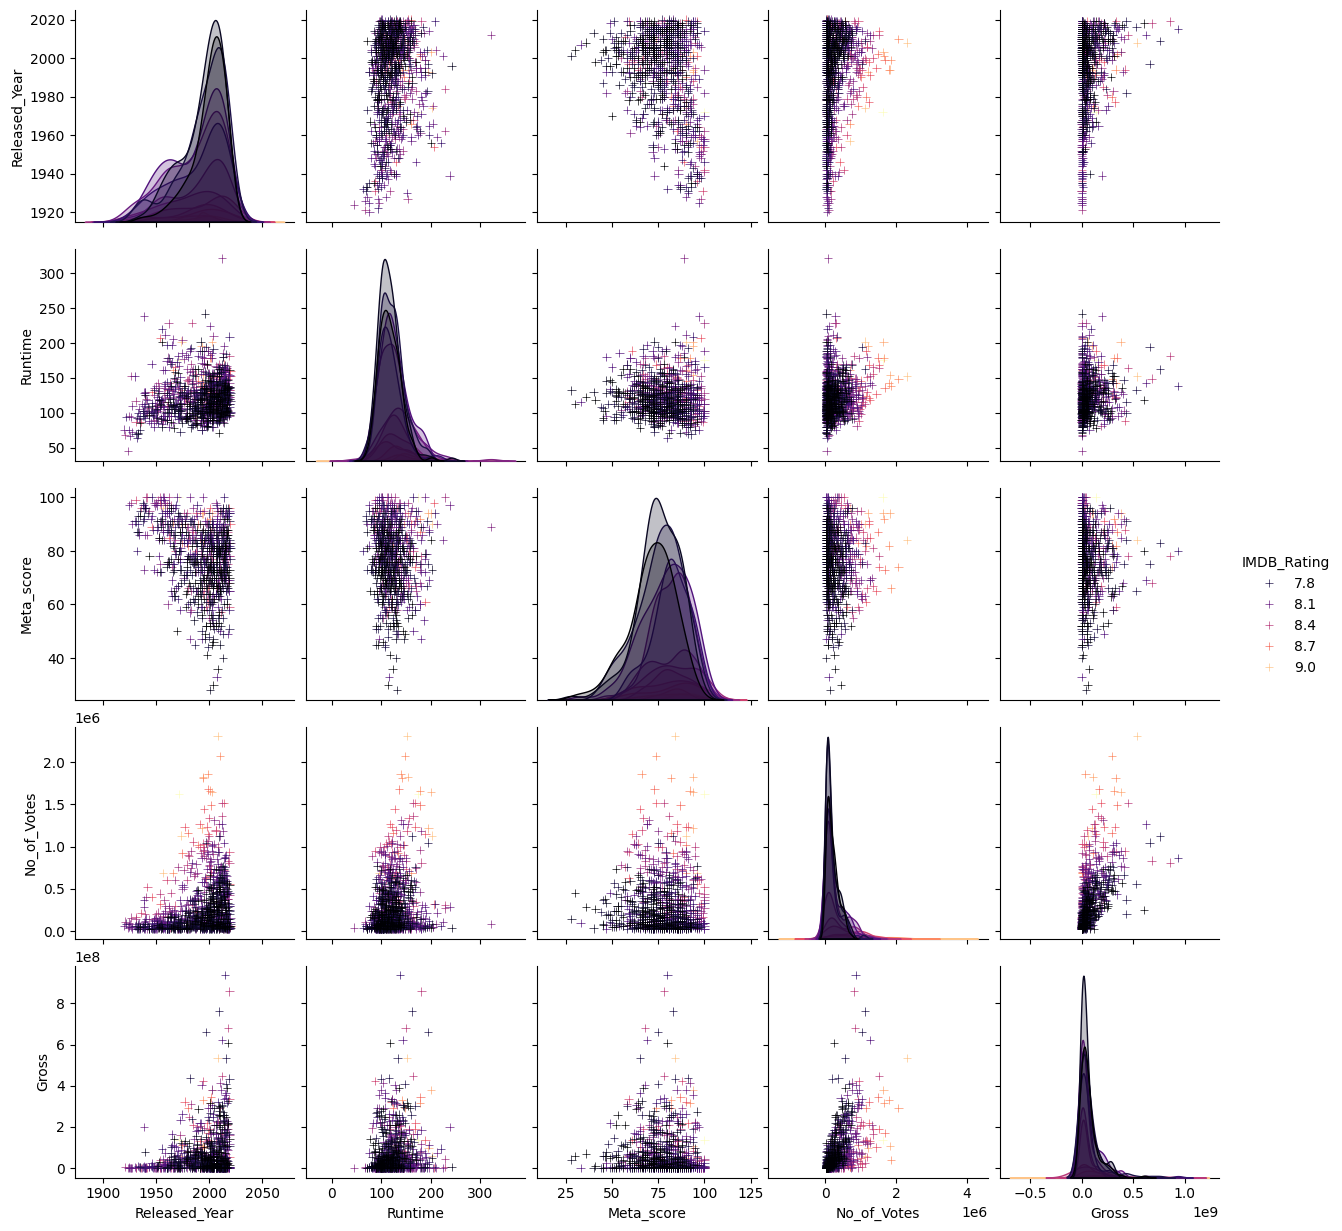

In [ ]:
sns.pairplot(df_movie, hue='IMDB_Rating', markers='+', palette = 'magma')
plt.show()

Podemos destacar as seguintes observações retidas nos histogramas e boxplots:


*   Released_Year -> A quantidade de filmes tendeu a crescer de acordo com o passar dos anos, ou seja, o histograma possui uma assimetria à direita. Isso mostra um crescimento acelerado da industria cinematográfica.
*   Runtime -> Os filmes tendem a ter uma duração entre 90 min a 120 min, onde fica o pico do grafico.
*   IMDB_Rating (target) -> Nossa variavel alvo, tem uma distribuição de assimétrica à direita devido ao seus valores estarem concentrados entre 7.6 e 8.5, evidenciando uma cauda a direita.
*   Meta_score -> Tem uma distribuição bimodal e multimodal tendo seus picos entorno de 50-60 e 70-80.
*   No_of_votes -> o histograma é extremamente assimétrico, mostrando desigualdade entre os filmes, uns sendo muito mais votados que os outros. Isso diz muito sobre popularidade
*   Gross -> Também bem assimétrica a direita assim como No_of_votes, evidenciando desigualdade entre os dados também.





### Analise Univariada Categóricas

Após analisar as variaveis numéricas vamos analisar as categóricas e ver como elas se correlacionam.

In [ ]:
#plotando
cert_hist = px.bar(df_movie['Certificate'],
                   x = df_movie['Certificate'].value_counts().index,
                   y = df_movie['Certificate'].value_counts().values,
                   color = df_movie['Certificate'].value_counts().index,
                   title = 'Quantidade de filmes por classificação',
                   template ='plotly_dark'
                   )
cert_hist.show()

A classificação 'U' (universais), predominante na industria, nos remete que a maior parte dos filmes é feito para todos os publicos. As classificações 'A' (adulto) e 'AU' (maiores de 12 anos ou menores acompanhados) também aparecem com uma boa frequencia, isso indica que filmes com essas classificações também são mais produzidos e consumidos.

Agora 'Passed', 'GP', 'Approved' são mais relacionados a filmes antigos nos EUA e agora são classificações em desuso, pois 'PG' e 'R' foram criados para substituir.


---



In [ ]:
map_certificado = {
    'A': 'Adulto',
    'U': 'Livre',
    'PG': 'Livre_Com_Acompanhamento',
    'PG-13': 'Adolescente',
    'R': 'Restrito',
    'NC-17': 'Adulto_Restrito'
}

df_movie['Certificate_Mapeado'] = df_movie['Certificate'].map(map_certificado).fillna('Outros')

O objetivo nesse bloco de código é "derreter" as três colunas de gêneros cinematográficos criadas para assim transformar em uma coluna apenas. Assim criando um novo dataframe onde contém a posição do generos (em qual coluna ele se encontrava) e o gênero cinematografico, assim podendo comparar com outras variaveis e criar insights interessantes.

In [ ]:
# derrete as colunas de genero, sendo possivel mudar a variavel id_vars
def melt_genres(df_movie, id_vars, genre_cols=['Genre_1', 'Genre_2', 'Genre_3']):
  df_genre_melted = pd.melt(         #Cria dataframe "derretido"
      df_movie, id_vars=id_vars,
      value_vars=genre_cols,
      var_name='Genre_Position',
      value_name='Genre'             # coluna derretida que pode ser chamada por Genre
    )
  return df_genre_melted.dropna(subset=['Genre'])

In [ ]:
# chamando a função e fixando 'director' para que não seja 'derretido' junto com os generos.
df_top_directors = melt_genres(df_movie, id_vars = ['Director'])
top_directors = df_movie['Director'].value_counts(ascending = False).head(20)

# fitra o nome dos diretores e registra a quantidade de filmes
df_top = df_top_directors[df_top_directors['Director'].isin(top_directors.index)]

# Calcula a quantidade de filmes para cada diretor
director_counts = df_top['Director'].value_counts().reset_index()
director_counts.columns = ['Director', 'Quantidade']

# Agrupando diretores e generos
director_genre_counts = df_top.groupby(['Director', 'Genre']).size().reset_index(name='Qtd_Filmes')

# plotando o grafico de popularidade dos diretores por quantidade de filmes feitos
top_directors = px.bar(director_counts,
             x = 'Quantidade',
             y = 'Director',
             color = 'Director',
             orientation = 'h',
             text_auto='.2s',
             title = 'Top 20 Diretores por Quantidade de Filmes',
             template ='plotly_dark'
             )
# grafico com os generos de filmes produzidos por cada diretor
most_genre = px.bar(director_genre_counts,
              x = 'Genre',
              color = 'Director',
              title = 'Diretores e Generos',
              template ='plotly_dark'
              )
top_directors.show()
most_genre.show()

### Generos x Faturamento x Popularidade

In [ ]:
!pip install jupyter_bokeh -q

In [ ]:
df_melted_gross = melt_genres(df_movie, id_vars = ['Gross'])
df_melted_gross.head(10)

,Gross,Genre_Position,Genre
0,134966411.0,Genre_1,Crime
1,534858444.0,Genre_1,Action
2,57300000.0,Genre_1,Crime
3,4360000.0,Genre_1,Crime
4,377845905.0,Genre_1,Action
5,107928762.0,Genre_1,Crime
6,96898818.0,Genre_1,Biography
7,292576195.0,Genre_1,Action
8,37030102.0,Genre_1,Drama
9,315544750.0,Genre_1,Action


Gênero mais comuns na industria cinematográfica

In [ ]:
# limpa os espaços vazios
df_melted_gross['Genre'] = df_melted_gross['Genre'].str.strip()

top_genres = df_melted_gross['Genre'].value_counts().reset_index()
top_genres.columns = ['Genre', 'Count']

# plotando o gráfico
pie = px.pie(top_genres.head(10),
             values='Count',
             names='Genre',
             title='Top 10 generos predominantes',
             template='plotly_dark'
            )
pie.update_traces(textposition = 'inside', textinfo = 'percent+label')
pie.show()

Gêneros que rendem mais bilheteria

In [ ]:
# calcula a média de faturamento por gênero
avg_gross_year = df_melted_gross.groupby(['Genre'])['Gross'].mean().reset_index()

# Plotando grafico
line = px.line(avg_gross_year,
               x = 'Genre',
               y = 'Gross',
               markers = True,
               text = 'Genre',
               title ='Média de faturamento por gênero',
               template ='plotly_dark')
line.show()

Notas do público x usuários do IMDB

In [ ]:
# Plotando gráfico com a média de notas IMDB em comparação com os anos
line_imdb = px.line(df_movie.groupby('Released_Year')['IMDB_Rating'].mean().reset_index(),
              x = 'Released_Year', y ='IMDB_Rating',
              markers = True,
              color_discrete_sequence=["seagreen"],
              title ='Evolução da média da nota do IMDB no decorrer dos anos',
              template ='plotly_dark'
              )

line_imdb.show()

In [ ]:
line_votes = px.line(df_movie.groupby('Released_Year')['No_of_Votes'].mean().reset_index(),
              x ='Released_Year', y ='No_of_Votes',
              markers = True,
              color_discrete_sequence=["orange"],
              title = 'Evolução da média de votos de espectadores ao decorrer dos anos',
              template ='plotly_dark'
              )
line_votes.show()

In [ ]:

line_gross = px.line(df_movie.groupby('Released_Year')['Gross'].mean().reset_index(),
              x ='Released_Year', y ='Gross',
              markers = True,
              color_discrete_sequence=["purple"],
              title = 'Evolução do faturamento no decorrer dos anos',
              template ='plotly_dark'
              )
line_gross.show()

Filmes que são mais populares entre os telespectadores

In [ ]:
# selecionando 20 filmes mais votados, do maior para o menor.
df_top_voted = df_movie.sort_values(by='No_of_Votes', ascending=False)[['Series_Title', 'IMDB_Rating', 'No_of_Votes']].head(20)
#
bar = px.bar(df_top_voted,
             x='Series_Title',
             y='No_of_Votes',
             color='No_of_Votes',
             title='20 filmes mais votados',
             text_auto='.2s', #colocando texto dentro da barra
             template ='plotly_dark'
            )
bar.show()

### **Conclusão:**

---



Apesar de Drama ser o gênero mais produzido no cinema, assim como consta o grafico de pizza, os generos Adventure, Sci-Fi e Action são os que mais chamam atenção do publico e geram maior valor de bilheteria, enquanto filmes Noir estão abaixo de todos os generos. Isso se deve ao faturamento ser menor nos anos anteriores a decada de 70, em comparação com hoje em dia.

### Recomendação de filme 📽

In [ ]:
# colocando os generos mais populares em evidência
most_pop_genre = ["Adventure", "Action", "Sci-Fi"]
padrao = "|".join(most_pop_genre)

# derretendo a coluna de genero
df_genre_melted =df_movie.melt(
    # percorre todas as colunas que serão fixas, menos aquelas que possuem genero
    id_vars=[col for col in df_movie.columns if not col.startswith('Genre')],
    value_vars=['Genre_1', 'Genre_2', 'Genre_3'],
    var_name='Genre_Type',
    value_name='Genre'
    )

# fitrando os generos
df_filtered = df_genre_melted[df_genre_melted['Genre'].isin(most_pop_genre)]

# Ordenar filme mais popular de acordo com o faturamento e numero de votos
Recomended = df_filtered.sort_values(by=["Gross", "No_of_Votes"], ascending=False).head(1)

# printando a tabela com o filme mais recomendado de acordo com os dados
print("\n Filme a ser recomendado com base nos dados:")
print(tabulate.tabulate(Recomended[["Series_Title", "Genre", "Gross", "No_of_Votes", "IMDB_Rating"]], headers='keys', tablefmt='fancy_grid'))


 Filme a ser recomendado com base nos dados:
╒═════╤════════════════════════════════════════════╤═════════╤═════════════╤═══════════════╤═══════════════╕
│     │ Series_Title                               │ Genre   │       Gross │   No_of_Votes │   IMDB_Rating │
╞═════╪════════════════════════════════════════════╪═════════╪═════════════╪═══════════════╪═══════════════╡
│ 476 │ Star Wars: Episode VII - The Force Awakens │ Action  │ 9.36662e+08 │        860823 │           7.9 │
╘═════╧════════════════════════════════════════════╧═════════╧═════════════╧═══════════════╧═══════════════╛


Levando em consideração toda a analise acima, os dados nos mostram que filmes com generos como ação são mais bem sucedidos comercialmente. Logo, o filme que é mais recomendado é Star Wars: Episode VII - The Force Awakens, pois ele possui um dos generos mais populares, a maior bilheteria do genero e engajamento populacional, além disso 7 é uma nota positiva proferida pela crítica.

### Quais são os principais fatores que estão relacionados com alta expectativa de faturamento de um filme?

Como podemos reter de toda a analise realizada até o momento, muito fatores estão relacionados com o faturamento de um filme, mas entre elas as principais são:

Engajamento do publico(`No_of_Votes`) -> possui uma correlação positiva de 0.59. Quanto maior o marketing, por exmplo, maior o sucesso pré-lançamento.

Nota do proprio IMDB (`IMDB_Rating`) -> Filmes bem avaliados pela critica atraem um maior publico que busca um bom filme.

Faira-etária (`Classificate`)-> Filmes com a indicação livre costuma chamar atenção de um publico maior e mais diveros, mais do que filmes adultos. Entretanto, filmes com classificação indicativa +18 também atrai um grande publico que deve ser considerado.

Diretores e elenco -> A presença de diretores e atores renomados costumam atrair bastante o publico.

### Overwiew

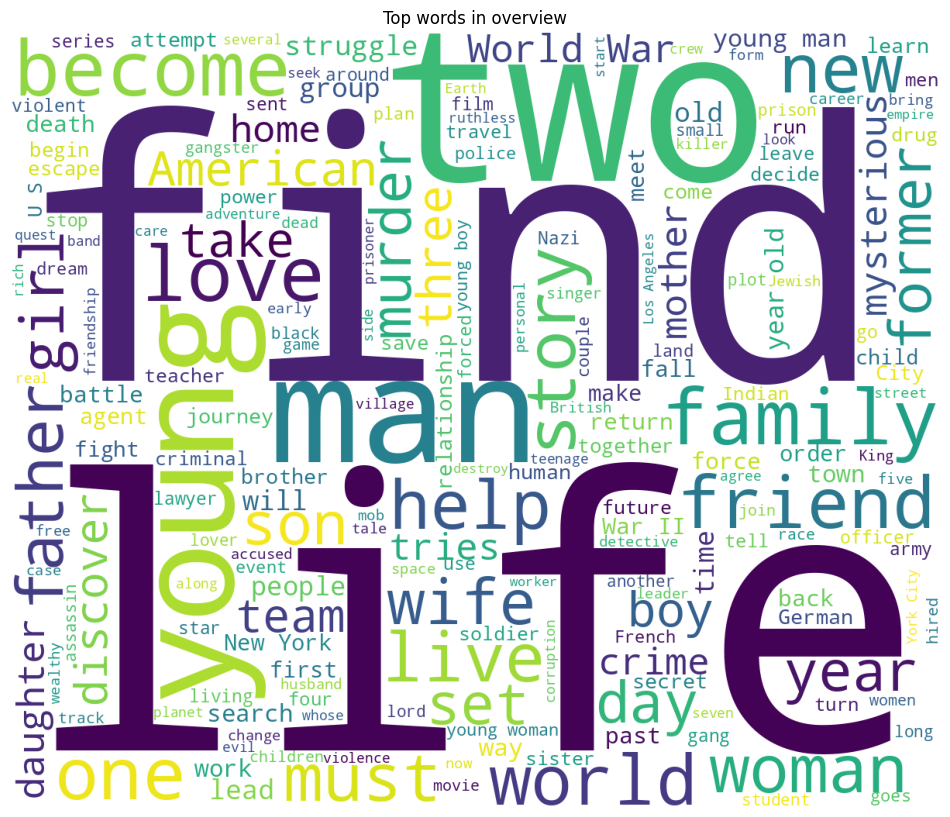

In [ ]:
# Biblioteca especifica para gerar nuvens de palavras
from wordcloud import WordCloud
# gera uma nuvem de palavras
plt.figure(figsize = (12, 12))
text = ' '.join(df_movie['Overview'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white', width=1200, height=1000).generate(text)
plt.imshow(wordcloud)
plt.title('Top words in overview')
plt.axis("off")
plt.show()

### Pré-Processamento para os modelos

Utilizando técnica de pré processamento para simplificar as estruturas das palavras

In [ ]:
import nltk #processamento de linguagem natural
import re #regex - manipulação de texto com expressões regulares
from nltk.corpus import stopwords # Lista de palavras comuns que geralmente são removidas (the, and, is, etc.)
from nltk.stem import WordNetLemmatizer #Reduz palavras à sua forma base (lematização)
from nltk.tokenize import word_tokenize # Divide texto em palavras individuais (tokenização)
from collections import Counter #Analisa frequência das palavras


nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# stopwords em inglês
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = word_tokenize(text)
    return [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

# aplicando a função clean_text
df_movie['overview'] = df_movie['Overview'].apply(clean_text)
df_movie['Word_Count'] = df_movie['overview'].apply(lambda x: len(x))

# Juntar todas as palavras mais frequentes de todas as overviews
all_words = [word for sublist in df_movie['overview'] for word in sublist]

# Contar frequência de cada palavra
word_freq = Counter(all_words)
top_20_words = word_freq.most_common(20)

print("Top 20 palavras mais frequentes:")
for word, count in top_20_words:
    print(f"{word}: {count}")

# dataframe criado com as palavras mais frequentes
word_data = []
for word, _ in top_20_words:
    # Filtrar filmes que contêm esta palavra na overview
    movies_with_word = df_movie[df_movie['overview'].apply(lambda x: word in x)]

    if len(movies_with_word) > 0:
        avg_rating = movies_with_word['IMDB_Rating'].mean()
        count_movies = len(movies_with_word)
        word_data.append({
            'Word': word,
            'Avg_IMDB_Rating': avg_rating,
            'Movie_Count': count_movies
        })

# Criar DataFrame
word_df = pd.DataFrame(word_data)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Top 20 palavras mais frequentes:
life: 136
young: 132
man: 116
two: 103
find: 101
world: 80
woman: 77
new: 72
family: 70
story: 68
love: 66
friend: 65
war: 62
one: 57
help: 52
boy: 52
must: 50
year: 48
father: 46
girl: 46


In [ ]:
# Scatter plot com tamanho baseado na frequência
word_freq_scatter = px.scatter(word_df,
                              x='Word',
                              y='Avg_IMDB_Rating',
                              size='Movie_Count',
                              color='Movie_Count',
                              title='Palavras mais frequêntes nas sinopses dos filmes vs Nota IMDB)',
                              template='plotly_dark')

word_freq_scatter.show()

 ### Tratando valores nulos

Em geral, quando os valores nulos estão acima de 50% é esperado que as colunas com esses valores sejam excluidas para assim não gerar ruidos, mas no nosso caso as colunas com ausensia de dados não passam de 36%. Primeiramente, vamos descobrir quais são as colunas afetas e trata-las individualmente:

In [ ]:
# grafico com a somatória de todos os valores nulos
null_bar = px.bar(df_movie.isnull().sum(),
                   x = df.isnull().sum().index,
                   y = df.isnull().sum().values,
                   color = df.isnull().sum(),
                   title = 'Quantidade de valores nulos por coluna',
                   template ='plotly_dark'
                   )
null_bar.show()

Podemos supor que a quantidade de valores nulos nas colunas de generos criada pode estar relacionada ao fato de alguns filmes não possuem 3  ou 2 gêneros, o que pode gerar uma lacuna entre os dados. Mas isso será ajeitado agora:

In [ ]:
# copia de df_movie para não afetar os dados anteriores
df_treated = df_movie.copy()
# removendo linhas da coluna Gross que não possuem informação sobre faturamento
df_treated = df_treated.dropna(axis = 0, subset = ['Gross'])
# substituindo valores vazio por desconhecido
df_treated['Certificate'] = df_treated['Certificate'].fillna('Unknown')
# Substituindo valores nulos pela mediana
df_treated['Meta_score'] = df_treated['Meta_score'].fillna(df_treated['Meta_score'].median())

print(f'\n df_treated antes do tratamento de nulos: \n{df_movie.isnull().sum()}')
print(f'\n df_treated depois do tratamento de nulos:\n{df_treated.isnull().sum()}')


 df_treated antes do tratamento de nulos: 
Series_Title             0
Released_Year            1
Certificate            101
Runtime                  0
IMDB_Rating              0
Overview                 0
Meta_score             157
Director                 0
Star1                    0
Star2                    0
Star3                    0
Star4                    0
No_of_Votes              0
Gross                  169
Genre_1                  0
Genre_2                104
Genre_3                353
Certificate_Mapeado      0
overview                 0
Word_Count               0
dtype: int64

 df_treated depois do tratamento de nulos:
Series_Title             0
Released_Year            1
Certificate              0
Runtime                  0
IMDB_Rating              0
Overview                 0
Meta_score               0
Director                 0
Star1                    0
Star2                    0
Star3                    0
Star4                    0
No_of_Votes              0
Gross   

Os valores nulos das colunas de gênero cinematográfico não foram tratadas pois elas serão trasnformadas com get_dummies.

Vamos escolher as variaveis que possuem valor preditivo (Features) para o nosso modelo, e dropar as que não são úteis para a analise.

In [ ]:
df_dummies = pd.get_dummies(df_treated, columns=['Certificate', 'Genre_1', 'Genre_2', 'Genre_3'], dtype = int)

numerical_cols = df_treated.select_dtypes(include=[np.number]).columns.tolist() # Pega as variaveis numéricas e transforma em uma lista
numerical_cols.remove('IMDB_Rating') # remove a variavel target
#definindo as features
df_feature = df_treated[numerical_cols]

# definindo as features como X e a target como y
X = df_feature
y = df_treated['IMDB_Rating']

In [ ]:
# Vetorizando a coluna Overwiew para virar dado de treino
vectorizer = TfidfVectorizer(max_features=1000)
X_overview_vectorized_train = vectorizer.fit_transform(df_treated.loc[X_train.index, 'Overview'].fillna(''))

### Regressão Linear Simples e Multipla

para começarmos a criar os modelos preditivos precisamos separa nosso dataset em uma base de treino e teste, para garantir que o modelo aprenda corretamente invés de apenas memorizar os dados, assim evitando overffiting.

In [89]:
# Importando bibliotecas necessárias para a regressão linear
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Removendo linhas que têm valores ausentes na coluna 'Released_Year'
df_treated.dropna(subset=['Released_Year'], inplace=True)

# Selecionando apenas as colunas numéricas para o modelo
numerical_cols = ['Runtime', 'Meta_score', 'No_of_Votes', 'Gross']

# Definindo variáveis preditoras (X) e alvo (y)
X = df_treated[numerical_cols]
y = df_treated['IMDB_Rating']

# Separando os dados em treino e teste (80% treino / 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronizando as variáveis numéricas (trazendo para a mesma escala)
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Criando e treinando o modelo de Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Fazendo previsões com os dados de teste
y_pred = lin_reg.predict(X_test)

# Função para interpretar o valor de R² em níveis (Baixa, Média, Alta explicação)
def r2_interpretation(r_squared):
  if r_squared < 0.3:
    return "Baixa"
  elif r_squared < 0.6:
    return "Média"
  else:
    return "Alta"

# Avaliando cada variável numérica individualmente em uma regressão simples
for var in numerical_cols:
    X_var = sm.add_constant(X_train[[var]])
    y_var = y_train

    model = sm.OLS(y_var, X_var).fit()
    coef = model.params
    r_squared = model.rsquared

    print(f"\n → Regressão usando a variável: {var}")
    print(f"R² no treino (todas as variáveis):", r2_score(y_train, lin_reg.predict(X_train)))
    print("R² no teste (todas as variáveis):", r2_score(y_test, y_pred))
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
    print(f"Equação: IMDB_Rating = {coef[0]:.2f} + ({coef[1]:.4f}) * {var}")
    print(f"R² (individual): {r_squared:.4f}")
    print(f"Nível de explicação (individual): {r2_interpretation(r_squared)}")



 → Regressão usando a variável: Runtime
R² no treino (todas as variáveis): 0.44250354010298487
R² no teste (todas as variáveis): 0.5102055167328644
RMSE: 0.20
Equação: IMDB_Rating = 7.95 + (0.0680) * Runtime
R² (individual): 0.0608
Nível de explicação (individual): Baixa

 → Regressão usando a variável: Meta_score
R² no treino (todas as variáveis): 0.44250354010298487
R² no teste (todas as variáveis): 0.5102055167328644
RMSE: 0.20
Equação: IMDB_Rating = 7.95 + (0.0799) * Meta_score
R² (individual): 0.0838
Nível de explicação (individual): Baixa

 → Regressão usando a variável: No_of_Votes
R² no treino (todas as variáveis): 0.44250354010298487
R² no teste (todas as variáveis): 0.5102055167328644
RMSE: 0.20
Equação: IMDB_Rating = 7.95 + (0.1438) * No_of_Votes
R² (individual): 0.2714
Nível de explicação (individual): Baixa

 → Regressão usando a variável: Gross
R² no treino (todas as variáveis): 0.44250354010298487
R² no teste (todas as variáveis): 0.5102055167328644
RMSE: 0.20
Equação: 

/tmp/ipython-input-1962815118.py:55: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-1962815118.py:55: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-1962815118.py:55: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipython-input-1962815118.py:55: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consi

observando individualmente cada feature através de uma *regressão linear simples* pode ser observado que elas sozinhas não possuem valor preditivo significativo, mas ao usar uma abordagem *multipla* (todas as features juntas) podemos ver um impacto muito maior (`0.5108837402831512`) delas na variavel target `IMDB_Rating`.

In [ ]:
# dataframe para colocar os dados de previsão x real
df_pred = pd.DataFrame({'Real': y_test, 'Previsto': y_pred})
scatter = px.scatter(df_pred,
             x = 'Real',
             y = 'Previsto',
             size = 'Real',
             hover_data= ['Previsto'],
             color = 'Real',
             template = 'plotly_dark',
             title = 'Regressão Linear Multipla: Real vs Previsto',
)
# Adiciona um linha de tendencia vermelha
scatter.add_shape(
    type="line",
    x0=df_pred["Real"].min(),
    y0=df_pred["Real"].min(),
    x1=df_pred["Real"].max(),
    y1=df_pred["Real"].max(),
    line=dict(color="red", dash="dash")
)
scatter.show()


### Conclusão:

---


Modelo de previsão de regressao linear multipla tem um desempenho superior ao simples. Algo também muito interessante de ser notado é que os valores de teste e treino são bem aproximados, mas o teste (dados que nunca viram os valores reais) não supera o treino. Isso deixa evidente que não há overffiting, o que é muito bom porque estamos evitando isso.
O scatterplot plotado nos dá uma representação visual de como o modelo está prevendo, sendo que quanto mais as bolinhas se aproximam da linha vermelha, melhor é a previsão. Em um cenário perfeito as bolinhas estariam completamente alinhadas com a linha, mas o fato de terem varias em volta dessa linha, já siginifica que nosso modelo está prevendo razoavelmente bem.

### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_regressor = RandomForestRegressor(n_estimators=100,    # Número de árvores
    max_depth=10,        # Limita a profundidade das árvores
    min_samples_split=10, # Mínimo de amostras para dividir um nó
    min_samples_leaf=5,   # Mínimo de amostras nas folhas
    random_state=42)
rf_regressor.fit(X_train, y_train)
# Previsão
y_pred = rf_regressor.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor Performance:")
print(f"R² no treino(todas as features): {r2_score(y_train, rf_regressor.predict(X_train)):.4f}")
print(f"R² no teste(todas as features): {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {rmse:.2f}")

Random Forest Regressor Performance:
R² no treino(todas as features): 0.7426
R² no teste(todas as features): 0.5743
RMSE: 0.19


In [ ]:
import joblib

# salvar
joblib.dump(rf_regressor, "rf_regressor.pkl")

# carregar
modelo_carregado = joblib.load("rf_regressor.pkl")

# testar
y_pred = modelo_carregado.predict(X_test)

Esse modelo foi o mais eficiente até o momento, tendo a maior precisão e menor pontos de erro em comparação com os outros.

In [ ]:
# datframe para colocar os dados de previsão x real
df_pred = pd.DataFrame({'Real': y_test, 'Previsto': y_pred})
scatter = px.scatter(df_pred,
             x = 'Real',
             y = 'Previsto',
             size = 'Real',
             hover_data= ['Previsto'],
             color = 'Real',
             template = 'plotly_dark',
             title = 'Random Forest Regressor: Real vs Previsto',
)
# Adiciona
scatter.add_shape(
    type="line",
    x0=df_pred["Real"].min(),
    y0=df_pred["Real"].min(),
    x1=df_pred["Real"].max(),
    y1=df_pred["Real"].max(),
    line=dict(color="red", dash="dash")
)
scatter.show()


### Conclusão:

---

O modelo de RandomForestRegressor se saiu um pouco melhor do que a regressão linear tanto no teste(57%) quanto no treino(74%), mas mostou sinais de overffiting devido ao valor do treino ser maior do que o teste. Isso diminui a precisão desse modelo. Algo também a se levar em consideração é o RMSE: 0.19, que erra em média 0.19 pontos em uma escala de 0 a 10, ou seja, é um ótimo valor para avaliação de filmes.

### XGB Boost Regressor

In [ ]:
from xgboost import XGBRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Selecionando as colunas numéricas como features
numerical_cols_to_use = ['Runtime', 'Meta_score', 'No_of_Votes', 'Gross']
X_numerico_train = X_train[numerical_cols_to_use]

# combinando as features numéricas junto com Overwiew
X_combined_train = hstack([X_numerico_train, X_overview_vectorized_train])

X_overview_vectorized_test = vectorizer.transform(df_treated.loc[X_test.index, 'Overview'].fillna(''))

X_numerico_test = X_test[numerical_cols_to_use]

X_combined_test = hstack([X_numerico_test, X_overview_vectorized_test])


# definindo features e target
X = X_combined_train
y = y_train

# treinando o modelo
xgb_regressor = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_regressor.fit(X, y)

# Previsão
y_pred = xgb_regressor.predict(X_combined_test)

# calcula a média de erros e o R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XBG Boost Regressor Performance:")
print(f"R² no treino(todas as features): {r2_score(y_train, xgb_regressor.predict(X_combined_train)):.4f}")
print(f"R² no teste(todas as features): {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {rmse:.2f}")

XBG Boost Regressor Performance:
R² no treino(todas as features): 0.9904
R² no teste(todas as features): 0.4819
RMSE: 0.21


Supondo os filmes com as seguintes caracteristicas:
{'Series_Title': 'The Shawshank Redemption',
 'Released_Year': '1994',
 'Certificate': 'A',
 'Runtime': '142 min',
 'Genre': 'Drama',
 'Overview': 'Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.',
 'Meta_score': 80.0,
 'Director': 'Frank Darabont',
 'Star1': 'Tim Robbins',
 'Star2': 'Morgan Freeman',
 'Star3': 'Bob Gunton',
 'Star4': 'William Sadler',
 'No_of_Votes': 2343110,
 'Gross': '28,341,469'}


Qual seria a nota do IMDB?


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define the vectorizer
vectorizer = TfidfVectorizer(max_features=1000) # You can adjust max_features as needed


vectorizer.fit(df_treated['Overview'].fillna(''))

TfidfVectorizer(max_features=1000)

In [90]:
# criando dataframe com as informações do filme
novo_filme = {
    'Series_Title': 'The Shawshank Redemption',
    'Released_Year': '1994',
    'Certificate': 'A',
    'Runtime': '142 min',
    'Genre': 'Drama',
    'Overview': 'Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.',
    'Meta_score': 80.0,
    'Director': 'Frank Darabont',
    'Star1': 'Tim Robbins',
    'Star2': 'Morgan Freeman',
    'Star3': 'Bob Gunton',
    'Star4': 'William Sadler',
    'No_of_Votes': 2343110,
    'Gross': '28,341,469'
}
# convertendo em dataframe
novo_df = pd.DataFrame([novo_filme])
# tratando runtime de string para int
novo_df['Runtime'] = novo_df['Runtime'].str.replace(" min", "", regex=False).astype(int)
# Gross de string para float
novo_df['Gross'] = novo_df['Gross'].str.replace(",", "", regex=False).astype(float)
# definindo o vetorizador
novo_df_vectorized = vectorizer.transform(novo_df['Overview'].fillna(''))

numerical_cols_to_use = ['Runtime', 'Meta_score', 'No_of_Votes', 'Gross']
X_numerico = novo_df[numerical_cols_to_use]

from scipy.sparse import hstack
X_final = hstack([X_numerico, novo_df_vectorized])

# predição da nota do imdb
pred = xgb_regressor.predict(X_final)
print("Nota prevista para o IMDB:", pred[0])

Nota prevista para o IMDB: 8.880733
